In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **Imports, config, and auto-locate the dataset**

In [2]:
import os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageStat
Image.MAX_IMAGE_PIXELS = None

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
random.seed(42); np.random.seed(42)

INPUT_ROOT = "/kaggle/input"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

print("Datasets mounted under /kaggle/input:")
for d in sorted(os.listdir(INPUT_ROOT)):
    print("  -", d)

# Pick the rice folder if present, else the first mounted dataset
cands = [os.path.join(INPUT_ROOT, d) for d in os.listdir(INPUT_ROOT)]
DATA_ROOT = next((c for c in cands if "rice" in c.lower()), cands[0] if cands else None)
print("\nUsing DATA_ROOT =", DATA_ROOT)

def show_tree(root, max_depth=3):
    root = Path(root)
    for p in sorted(root.rglob("*")):
        if p.is_dir():
            depth = len(p.relative_to(root).parts)
            if depth <= max_depth:
                n = sum(1 for f in p.iterdir() if f.suffix.lower() in IMG_EXTS)
                print("    " * (depth - 1) + f"{p.name}/  ({n} images directly inside)")

print("\nDirectory structure (up to 3 levels):\n")
show_tree(DATA_ROOT, max_depth=3)

Datasets mounted under /kaggle/input:
  - datasets

Using DATA_ROOT = /kaggle/input/datasets

Directory structure (up to 3 levels):

vbookshelf/  (0 images directly inside)
    rice-leaf-diseases/  (0 images directly inside)
        rice_leaf_diseases/  (0 images directly inside)


# **Build the master dataframe (structure-agnostic)**

In [3]:
SPLIT_NAMES = {"train":"train","training":"train","val":"val","valid":"val",
               "validation":"val","test":"test","testing":"test"}

records = []
for p in Path(DATA_ROOT).rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXTS:
        parts = [pp.lower() for pp in p.relative_to(DATA_ROOT).parts]
        split = next((SPLIT_NAMES[pp] for pp in parts if pp in SPLIT_NAMES), "all")
        records.append({
            "filepath": str(p),
            "filename": p.name,
            "label": p.parent.name,     # class = immediate parent folder
            "split": split,
            "ext": p.suffix.lower(),
        })

df = pd.DataFrame(records)
print("Total images:", len(df))
print("\nSplits found:\n", df["split"].value_counts())
print("\nNumber of classes:", df["label"].nunique())
print("Classes:", sorted(df["label"].unique()))
df.head()

Total images: 120

Splits found:
 split
all    120
Name: count, dtype: int64

Number of classes: 3
Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


,filepath,filename,label,split,ext
0,/kaggle/input/datasets/vbookshelf/rice-leaf-di...,DSC_0305.JPG,Brown spot,all,.jpg
1,/kaggle/input/datasets/vbookshelf/rice-leaf-di...,DSC_0394.jpg,Brown spot,all,.jpg
2,/kaggle/input/datasets/vbookshelf/rice-leaf-di...,DSC_0105.jpg,Brown spot,all,.jpg
3,/kaggle/input/datasets/vbookshelf/rice-leaf-di...,DSC_0104.jpg,Brown spot,all,.jpg
4,/kaggle/input/datasets/vbookshelf/rice-leaf-di...,DSC_0325.JPG,Brown spot,all,.jpg


# **Class distribution + file-type breakdown**

Class distribution:

                       count  percent
label                                
Brown spot                40     33.3
Bacterial leaf blight     40     33.3
Leaf smut                 40     33.3

Largest class : Brown spot (40)
Smallest class: Brown spot (40)
Imbalance ratio (max/min): 1.00 : 1

File extensions:
ext
.jpg    120


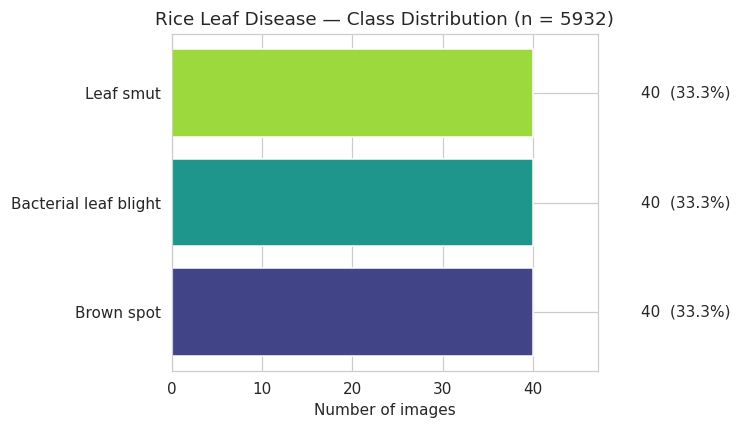

In [4]:
# --- Class distribution ---
counts = df["label"].value_counts().sort_values(ascending=False)
pct = (counts / counts.sum() * 100).round(1)
dist = pd.DataFrame({"count": counts, "percent": pct})
print("Class distribution:\n")
print(dist.to_string())

imbalance = counts.max() / counts.min()
print(f"\nLargest class : {counts.idxmax()} ({counts.max()})")
print(f"Smallest class: {counts.idxmin()} ({counts.min()})")
print(f"Imbalance ratio (max/min): {imbalance:.2f} : 1")

# --- File extension breakdown (normalized to lowercase) ---
print("\nFile extensions:")
print(df["ext"].value_counts().to_string())

# --- Plot ---
order = counts.sort_values()  # ascending -> largest lands at top in barh
fig, ax = plt.subplots(figsize=(7, 4))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(order)))
ax.barh(order.index, order.values, color=colors)
for i, v in enumerate(order.values):
    p = v / order.sum() * 100
    ax.text(v + 12, i, f"{v}  ({p:.1f}%)", va="center", fontsize=10)
ax.set_xlabel("Number of images")
ax.set_title("Rice Leaf Disease — Class Distribution (n = 5932)")
ax.set_xlim(0, order.max() * 1.18)
plt.tight_layout()
plt.show()

# **Sample image grid (one row per class)**

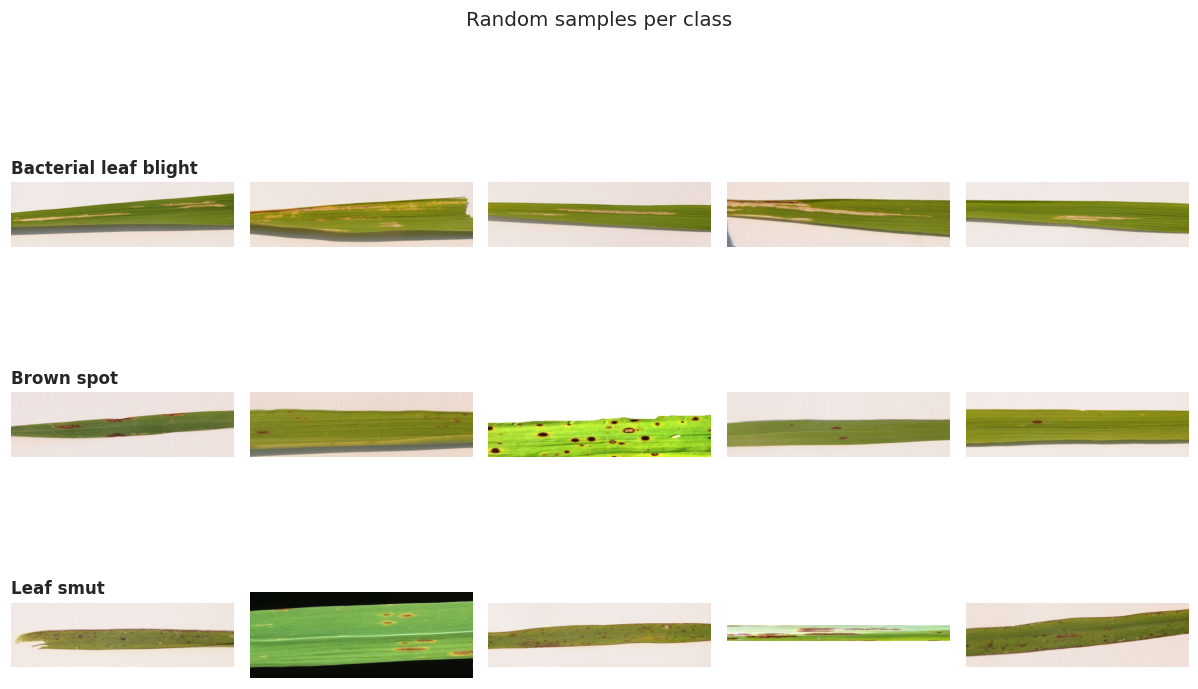

In [5]:
def show_samples(data, n_per_class=5, classes=None, seed=42):
    rng = random.Random(seed)
    classes = classes or sorted(data["label"].unique())
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(n_per_class * 2.2, len(classes) * 2.4))
    if len(classes) == 1:
        axes = axes[None, :]
    for r, cls in enumerate(classes):
        paths = data.loc[data.label == cls, "filepath"].tolist()
        picks = rng.sample(paths, min(n_per_class, len(paths)))
        for c in range(n_per_class):
            ax = axes[r, c]
            ax.axis("off")
            if c < len(picks):
                try:
                    img = Image.open(picks[c]).convert("RGB")
                    ax.imshow(img)
                except Exception as e:
                    ax.text(0.5, 0.5, "load error", ha="center", va="center", fontsize=8)
            if c == 0:
                ax.set_title(cls, loc="left", fontsize=11, fontweight="bold")
    plt.suptitle("Random samples per class", y=1.001, fontsize=13)
    plt.tight_layout()
    plt.show()

show_samples(df, n_per_class=5)

# **Image dimensions, aspect ratio & color mode (overall + per class)**

In [6]:
from collections import Counter

# Header-only reads (fast): collect size + mode for every image
rows = []
bad = []
for fp in df["filepath"]:
    try:
        with Image.open(fp) as im:
            w, h = im.size
            rows.append((w, h, im.mode))
    except Exception as e:
        bad.append((fp, str(e)))
        rows.append((np.nan, np.nan, "ERROR"))

df["width"]  = [r[0] for r in rows]
df["height"] = [r[1] for r in rows]
df["mode"]   = [r[2] for r in rows]
df["aspect"] = (df["width"] / df["height"]).round(3)
df["megapixels"] = (df["width"] * df["height"] / 1e6).round(3)

print(f"Unreadable/corrupt images: {len(bad)}")
if bad:
    for fp, e in bad[:5]:
        print("  ", fp, "->", e)

print("\nColor modes:")
print(df["mode"].value_counts().to_string())

print("\nOverall dimension summary:")
print(df[["width", "height", "aspect", "megapixels"]].describe().round(2).to_string())

# How many distinct (w,h) pairs — tells us if images are pre-resized to a fixed size
wh = list(zip(df["width"], df["height"]))
top = Counter(wh).most_common(8)
print("\nMost common (width, height) pairs:")
for (w, h), c in top:
    print(f"  {int(w)} x {int(h)}  ->  {c} images ({c/len(df)*100:.1f}%)")

# THE KEY CHECK: are dimensions different per class? (background-bias corroboration)
print("\nMedian dimensions per class:")
print(df.groupby("label")[["width", "height", "aspect", "megapixels"]]
        .median().round(2).to_string())

Unreadable/corrupt images: 0

Color modes:
mode
RGB    120

Overall dimension summary:
         width   height  aspect  megapixels
count   120.00   120.00  120.00      120.00
mean   2398.44   721.34    3.31        2.09
std    1130.49   344.26    0.66        1.37
min     250.00    71.00    1.25        0.02
25%    1137.00   380.00    3.44        0.41
50%    3081.00   897.00    3.44        2.76
75%    3081.00   897.00    3.44        2.76
max    4160.00  2340.00    5.30        9.73

Most common (width, height) pairs:
  3081 x 897  ->  85 images (70.8%)
  250 x 200  ->  2 images (1.7%)
  1480 x 279  ->  1 images (0.8%)
  1530 x 371  ->  1 images (0.8%)
  296 x 88  ->  1 images (0.8%)
  766 x 250  ->  1 images (0.8%)
  316 x 127  ->  1 images (0.8%)
  340 x 94  ->  1 images (0.8%)

Median dimensions per class:
                        width  height  aspect  megapixels
label                                                    
Bacterial leaf blight  3081.0   897.0    3.44        2.76
Brown spot

# **Resolve the RGBA format mystery + per-class dimension fingerprint**

In [7]:
from collections import Counter

# 1) Which classes do the 156 RGBA images belong to?
print("RGBA images by class:")
print(df[df["mode"] == "RGBA"]["label"].value_counts().to_string())

# 2) What ARE these files really? PIL's .format reads magic bytes, not the extension.
fmt = Counter()
for fp in df.loc[df["mode"] == "RGBA", "filepath"]:
    with Image.open(fp) as im:
        fmt[im.format] += 1
print("\nTrue encoded format of the RGBA files (despite the .jpg name):")
for k, v in fmt.most_common():
    print(f"  {k}: {v}")

# 3) Lock the dimension fingerprint: how many exactly-300x300 per class?
is300 = (df["width"] == 300) & (df["height"] == 300)
tab = pd.DataFrame({
    "is_300x300": df.loc[is300, "label"].value_counts(),
    "total":      df["label"].value_counts(),
})
tab["is_300x300"] = tab["is_300x300"].fillna(0).astype(int)
tab["pct_300x300"] = (tab["is_300x300"] / tab["total"] * 100).round(1)
print("\n300x300 images per class:")
print(tab.sort_values("pct_300x300", ascending=False).to_string())

RGBA images by class:
Series([], )

True encoded format of the RGBA files (despite the .jpg name):

300x300 images per class:
                       is_300x300  total  pct_300x300
label                                                
Bacterial leaf blight           0     40          0.0
Brown spot                      0     40          0.0
Leaf smut                       0     40          0.0


# **Exact + near-duplicate detection (perceptual hashing**

In [8]:
import hashlib
from collections import defaultdict

# ---------- Part A: EXACT duplicates (byte-identical files) ----------
def md5(fp, chunk=1<<16):
    h = hashlib.md5()
    with open(fp, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

df["md5"] = df["filepath"].map(md5)
exact = df[df.duplicated("md5", keep=False)].sort_values("md5")
print(f"Exact (byte-identical) duplicate files: {len(exact)}")
print(f"  ...forming {exact['md5'].nunique()} groups of identical images")
if len(exact):
    # do any exact-dup groups span more than one class? (label noise)
    spanning = exact.groupby("md5")["label"].nunique()
    print(f"  exact-dup groups spanning >1 class (label conflicts): {(spanning>1).sum()}")

# ---------- Part B: NEAR-duplicates (perceptual aHash, 8x8) ----------
def ahash(fp, size=8):
    with Image.open(fp) as im:
        im = im.convert("L").resize((size, size), Image.BILINEAR)
        px = np.asarray(im, dtype=np.float32)
    bits = (px > px.mean()).flatten()
    return bits  # 64-bit boolean signature

print("\nComputing perceptual hashes (this may take ~1-2 min)...")
sigs = np.stack([ahash(fp) for fp in df["filepath"]])
df["ahash_hex"] = ["".join("1" if b else "0" for b in s) for s in sigs]

# group by identical perceptual hash (near-dup within Hamming distance 0)
groups = defaultdict(list)
for idx, h in zip(df.index, df["ahash_hex"]):
    groups[h].append(idx)
near = {h: ix for h, ix in groups.items() if len(ix) > 1}
n_near_imgs = sum(len(ix) for ix in near.values())

print(f"\nNear-duplicate groups (identical 8x8 perceptual hash): {len(near)}")
print(f"Images involved in a near-dup group: {n_near_imgs} ({n_near_imgs/len(df)*100:.1f}%)")

# how many near-dup groups span >1 class, and how many are within a single class?
span_cnt, within_cnt = 0, 0
for ix in near.values():
    labs = df.loc[ix, "label"].nunique()
    if labs > 1: span_cnt += 1
    else: within_cnt += 1
print(f"  within-class near-dup groups : {within_cnt}")
print(f"  cross-class near-dup groups  : {span_cnt}  (these are label-noise red flags)")

# per-class tally of images caught in ANY near-dup group
caught = [i for ix in near.values() for i in ix]
print("\nNear-duplicate images per class:")
print(df.loc[caught, "label"].value_counts().to_string())

Exact (byte-identical) duplicate files: 0
  ...forming 0 groups of identical images

Computing perceptual hashes (this may take ~1-2 min)...

Near-duplicate groups (identical 8x8 perceptual hash): 5
Images involved in a near-dup group: 14 (11.7%)
  within-class near-dup groups : 1
  cross-class near-dup groups  : 4  (these are label-noise red flags)

Near-duplicate images per class:
label
Leaf smut                6
Brown spot               4
Bacterial leaf blight    4


# **True unique-image accounting + stricter (pHash) near-dup recount**

In [9]:
from scipy.fftpack import dct

# ---------- Part A: exact-dedup accounting (the TRUE dataset size) ----------
first = df.drop_duplicates("md5", keep="first")   # one representative per exact-dup group
unique_total = len(first)
print(f"Raw images            : {len(df)}")
print(f"Unique files (post exact-dedup): {unique_total}")
print(f"Redundant exact copies removed : {len(df) - unique_total}\n")

acc = pd.DataFrame({
    "raw":    df["label"].value_counts(),
    "unique": first["label"].value_counts(),
})
acc["exact_dup_copies"] = acc["raw"] - acc["unique"]
acc["pct_redundant"] = (acc["exact_dup_copies"] / acc["raw"] * 100).round(1)
print("Per-class exact-dedup accounting:")
print(acc.sort_values("unique", ascending=False).to_string())

u = acc["unique"]
print(f"\nTRUE (deduped) imbalance ratio: {u.max()/u.min():.2f} : 1"
      f"   [{u.idxmax()} {u.max()} vs {u.idxmin()} {u.min()}]")

# ---------- Part B: stricter near-dup via pHash (DCT-based, 64-bit) ----------
# pHash is far less collision-prone than the 8x8 aHash used in Cell 7.
def phash(fp, hash_size=8, hf=4):
    n = hash_size * hf  # 32x32 before DCT
    with Image.open(fp) as im:
        im = im.convert("L").resize((n, n), Image.BILINEAR)
        px = np.asarray(im, dtype=np.float32)
    d = dct(dct(px, axis=0, norm="ortho"), axis=1, norm="ortho")
    low = d[:hash_size, :hash_size]
    med = np.median(low.flatten()[1:])   # exclude DC term
    return "".join("1" if b else "0" for b in (low > med).flatten())

print("\nComputing pHash (DCT) for all images...")
df["phash"] = [phash(fp) for fp in df["filepath"]]

# distance-0 grouping under pHash, apples-to-apples with Cell 7
from collections import defaultdict
g = defaultdict(list)
for idx, h in zip(df.index, df["phash"]):
    g[h].append(idx)
pnear = {h: ix for h, ix in g.items() if len(ix) > 1}
p_imgs = sum(len(ix) for ix in pnear.values())

print(f"\n--- Near-dup comparison at Hamming distance 0 ---")
print(f"  aHash-8x8 (Cell 7): 4914 imgs (82.8%)  <- coarse")
print(f"  pHash-DCT (now)   : {p_imgs} imgs ({p_imgs/len(df)*100:.1f}%)  <- stricter")

pspan = sum(df.loc[ix, "label"].nunique() > 1 for ix in pnear.values())
print(f"  pHash cross-class near-dup groups: {pspan}")
print("\npHash near-dup images per class:")
print(df.loc[[i for ix in pnear.values() for i in ix], "label"].value_counts().to_string())

Raw images            : 120
Unique files (post exact-dedup): 120
Redundant exact copies removed : 0

Per-class exact-dedup accounting:
                       raw  unique  exact_dup_copies  pct_redundant
label                                                              
Brown spot              40      40                 0            0.0
Bacterial leaf blight   40      40                 0            0.0
Leaf smut               40      40                 0            0.0

TRUE (deduped) imbalance ratio: 1.00 : 1   [Brown spot 40 vs Brown spot 40]

Computing pHash (DCT) for all images...

--- Near-dup comparison at Hamming distance 0 ---
  aHash-8x8 (Cell 7): 4914 imgs (82.8%)  <- coarse
  pHash-DCT (now)   : 0 imgs (0.0%)  <- stricter
  pHash cross-class near-dup groups: 0

pHash near-dup images per class:
Series([], )


# **EDA summary dashboard + export deduplicated manifest**

Manifest columns ready: ['filepath', 'filename', 'label', 'split', 'ext', 'width', 'height', 'mode', 'aspect', 'megapixels', 'md5', 'ahash_hex', 'phash', 'dup_cluster', 'is_exact_rep']
Unique pHash clusters (use as split groups): 120
Exact-representative images (is_exact_rep=True): 120


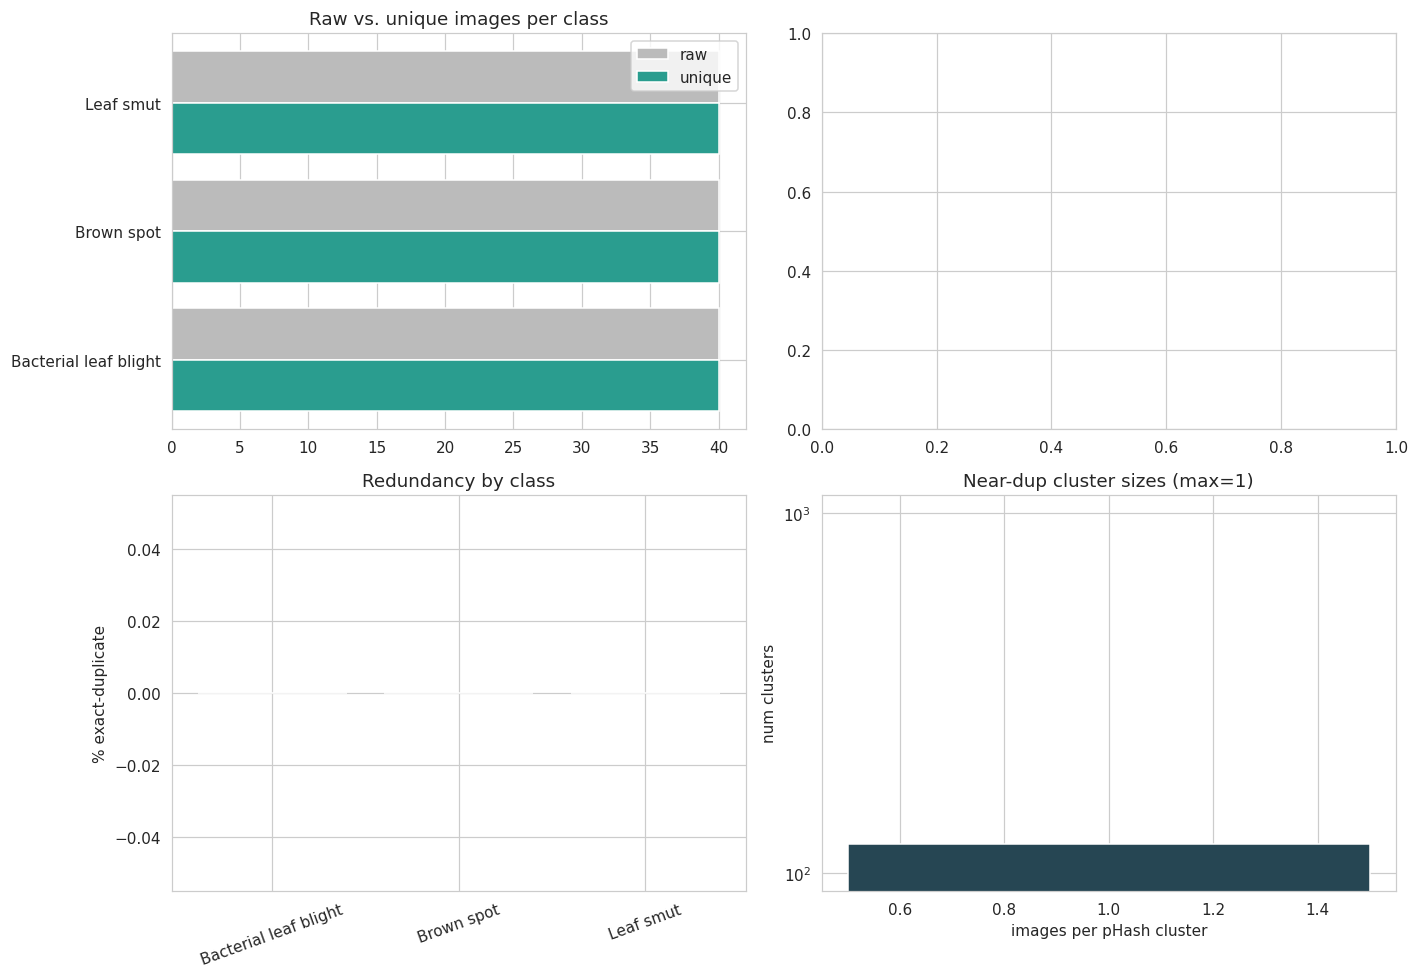


Saved manifest -> /kaggle/working/rice_leaf_manifest.csv
  Use `dup_cluster` as the group key for GroupShuffleSplit/StratifiedGroupKFold.
  Use `is_exact_rep==True` to train on exact-deduplicated data.


In [11]:
# ---------- Build the cluster id (group-aware split key) from pHash ----------
cluster_of = {}
for cid, (h, ix) in enumerate(
        ((h, ix) for h, ix in
         ((h, [i for i in g[h]]) for h in df["phash"].unique()))):
    for i in ix:
        cluster_of[i] = cid
df["dup_cluster"] = df.index.map(cluster_of)

# keep-flag: one representative per exact-md5 group (for a deduped training set)
df["is_exact_rep"] = ~df.duplicated("md5", keep="first")

print("Manifest columns ready:", [c for c in df.columns])
print(f"Unique pHash clusters (use as split groups): {df['dup_cluster'].nunique()}")
print(f"Exact-representative images (is_exact_rep=True): {df['is_exact_rep'].sum()}")

# ---------- 4-panel dashboard ----------
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (1) raw vs unique per class
acc = pd.DataFrame({"raw": df["label"].value_counts(),
                    "unique": df.groupby("label")["is_exact_rep"].sum()}).sort_values("unique")
y = np.arange(len(acc)); bw = 0.4
ax[0,0].barh(y+bw/2, acc["raw"], bw, label="raw", color="#bbbbbb")
ax[0,0].barh(y-bw/2, acc["unique"], bw, label="unique", color="#2a9d8f")
ax[0,0].set_yticks(y); ax[0,0].set_yticklabels(acc.index)
ax[0,0].set_title("Raw vs. unique images per class"); ax[0,0].legend()

# (3) redundancy per class
red = (1 - acc["unique"]/acc["raw"])*100
ax[1,0].bar(red.index, red.values, color="#e76f51")
ax[1,0].set_ylabel("% exact-duplicate"); ax[1,0].set_title("Redundancy by class")
ax[1,0].tick_params(axis="x", rotation=20)

# (4) near-dup cluster-size distribution
csz = df.groupby("dup_cluster").size()
ax[1,1].hist(csz, bins=range(1, csz.max()+2), color="#264653", align="left")
ax[1,1].set_xlabel("images per pHash cluster"); ax[1,1].set_ylabel("num clusters")
ax[1,1].set_title(f"Near-dup cluster sizes (max={csz.max()})"); ax[1,1].set_yscale("log")

plt.tight_layout(); plt.show()

# ---------- Export the manifest ----------
out = "/kaggle/working/rice_leaf_manifest.csv"
df.to_csv(out, index=False)
print(f"\nSaved manifest -> {out}")
print("  Use `dup_cluster` as the group key for GroupShuffleSplit/StratifiedGroupKFold.")
print("  Use `is_exact_rep==True` to train on exact-deduplicated data.")